# Association Rule Mining (FP-Growth)

import

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

load , save

In [3]:
INPUT_PATH = "../data/processed_transactions/cleaned_transactions.pkl"
CHARTS_OUTPUT = "../visualizations/charts/"
os.makedirs(CHARTS_OUTPUT, exist_ok=True)

basket = pd.read_pickle(INPUT_PATH)
transactions = basket['title'].tolist()

print(f"Loaded {len(transactions)} transactions from {INPUT_PATH}")

Loaded 2966 transactions from ../data/processed_transactions/cleaned_transactions.pkl


# Transaction Encoding (one hot encoding)

In [4]:
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f" Encoded Data Shape: {df_encoded.shape}")

 Encoded Data Shape: (2966, 21783)


# Frequent Itemsets Generation (fp growth)

**Support Equation:**
$$Support(A) = \frac{\text{Transactions containing } A}{\text{Total Transactions}}$$

In [5]:
frequent_itemsets = fpgrowth(df_encoded, min_support=0.001, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)

print(f" Found {len(frequent_itemsets)} frequent itemsets.")
if not frequent_itemsets.empty:
    print(frequent_itemsets.head(5))

 Found 1238 frequent itemsets.
      support                                           itemsets
135  0.024612  (Fire TV Stick with Alexa Voice Remote, stream...
175  0.022252  (Echo Dot (2nd Generation) - Smart speaker wit...
124  0.016858  (Fire TV Stick 4K streaming device with Alexa ...
164  0.016183  (Echo Dot (3rd Gen, 2018 release) - Smart spea...
93   0.015509  (Fire Tablet with Alexa, 7" Display, 16 GB, Bl...


# Association Rules

*   **Confidence:** $$Confidence(A \rightarrow B) = \frac{Support(A \cup B)}{Support(A)}$$
*   **Lift:** $$Lift(A \rightarrow B) = \frac{Support(A \cup B)}{Support(A) \times Support(B)}$$
*   **Leverage:** $$Leverage(A \rightarrow B) = Support(A \cup B) - (Support(A) \times Support(B))$$
*   **Conviction:** $$Conviction(A \rightarrow B) = \frac{1 - Support(B)}{1 - Confidence(A \rightarrow B)}$$
*   **Certainty Factor (CF):** $$CF = \frac{Confidence - Support(B)}{1 - Support(B)}$$

In [6]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.01)

if not rules.empty:
    rules['certainty_factor'] = (rules['confidence'] - rules['consequent support']) / (1 - rules['consequent support'])
    
    rules = rules.sort_values(by=['certainty_factor', 'lift'], ascending=False)
    
    print(f" Generated {len(rules)} rules.")
    display(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'certainty_factor','leverage','conviction']].head(10))
else:
    print(" No rules found yet. Try increasing the dataset rows in your preprocessing notebook.")

 Generated 114 rules.


,antecedents,consequents,support,confidence,lift,certainty_factor,leverage,conviction
54,"(Lexar E-Series 128GB Micro SD Card 2 Pack, mi...",(SABRENT Rocket 32GB DDR4 SO-DIMM 3200MHz Memo...,0.001011,1.0,988.666667,1.0,0.001010,inf
59,(SABRENT Rocket 32GB DDR4 SO-DIMM 3200MHz Memo...,"(Lexar E-Series 128GB Micro SD Card 2 Pack, mi...",0.001011,1.0,988.666667,1.0,0.001010,inf
78,(16 FT Inflatable Projector Movie Screen for O...,(NexFoto 32GB Large 15 inch Digital Picture Fr...,0.001011,1.0,988.666667,1.0,0.001010,inf
79,(NexFoto 32GB Large 15 inch Digital Picture Fr...,(16 FT Inflatable Projector Movie Screen for O...,0.001011,1.0,988.666667,1.0,0.001010,inf
24,"(USB Flash Drive Bulk 10 Pack, Exmapor 2GB USB...",(ROOFULL External CD DVD Drive USB 3.0 Type-C ...,0.001011,1.0,741.500000,1.0,0.001010,inf
81,"(DYMO LabelWriter 5XL Label Printer, Automatic...",(Cobra Smart Dash Cam + Rear Cam (SC 200D) – Q...,0.001011,1.0,741.500000,1.0,0.001010,inf
94,(Ethernet Cable 25 ft Cat 7 [10Gbps High Speed...,"(TBMax Cat 8 Ethernet Cable 25 ft, High Speed ...",0.001011,1.0,741.500000,1.0,0.001010,inf
55,"(Lexar E-Series 128GB Micro SD Card 2 Pack, mi...",(NETGEAR Orbi Pro WiFi 6 Tri-Band Mesh System ...,0.001011,1.0,593.200000,1.0,0.001010,inf
63,(SABRENT Rocket 32GB DDR4 SO-DIMM 3200MHz Memo...,(NETGEAR Orbi Pro WiFi 6 Tri-Band Mesh System ...,0.001011,1.0,593.200000,1.0,0.001010,inf
56,(NETGEAR Orbi Pro WiFi 6 Tri-Band Mesh System ...,"(Lexar E-Series 128GB Micro SD Card 2 Pack, mi...",0.001011,1.0,423.714286,1.0,0.001009,inf


# Sorting by CF and Lift to find most "Certain" rules

In [7]:
rules = rules.sort_values(by=[ 'lift'], ascending=False)


print(f" Generated {len(rules)} rules with full metrics.")
rules[['antecedents', 'consequents','lift']].head(10)

 Generated 114 rules with full metrics.


,antecedents,consequents,lift
54,"(Lexar E-Series 128GB Micro SD Card 2 Pack, mi...",(SABRENT Rocket 32GB DDR4 SO-DIMM 3200MHz Memo...,988.666667
59,(SABRENT Rocket 32GB DDR4 SO-DIMM 3200MHz Memo...,"(Lexar E-Series 128GB Micro SD Card 2 Pack, mi...",988.666667
78,(16 FT Inflatable Projector Movie Screen for O...,(NexFoto 32GB Large 15 inch Digital Picture Fr...,988.666667
79,(NexFoto 32GB Large 15 inch Digital Picture Fr...,(16 FT Inflatable Projector Movie Screen for O...,988.666667
24,"(USB Flash Drive Bulk 10 Pack, Exmapor 2GB USB...",(ROOFULL External CD DVD Drive USB 3.0 Type-C ...,741.500000
81,"(DYMO LabelWriter 5XL Label Printer, Automatic...",(Cobra Smart Dash Cam + Rear Cam (SC 200D) – Q...,741.500000
94,(Ethernet Cable 25 ft Cat 7 [10Gbps High Speed...,"(TBMax Cat 8 Ethernet Cable 25 ft, High Speed ...",741.500000
95,"(TBMax Cat 8 Ethernet Cable 25 ft, High Speed ...",(Ethernet Cable 25 ft Cat 7 [10Gbps High Speed...,741.500000
25,(ROOFULL External CD DVD Drive USB 3.0 Type-C ...,"(USB Flash Drive Bulk 10 Pack, Exmapor 2GB USB...",741.500000
80,(Cobra Smart Dash Cam + Rear Cam (SC 200D) – Q...,"(DYMO LabelWriter 5XL Label Printer, Automatic...",741.500000


visulaization

C:\Users\Matrix\AppData\Local\Temp\ipykernel_12452\901730839.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


Visualization saved successfully to: ../visualizations/charts/top_rules_lift_final.png


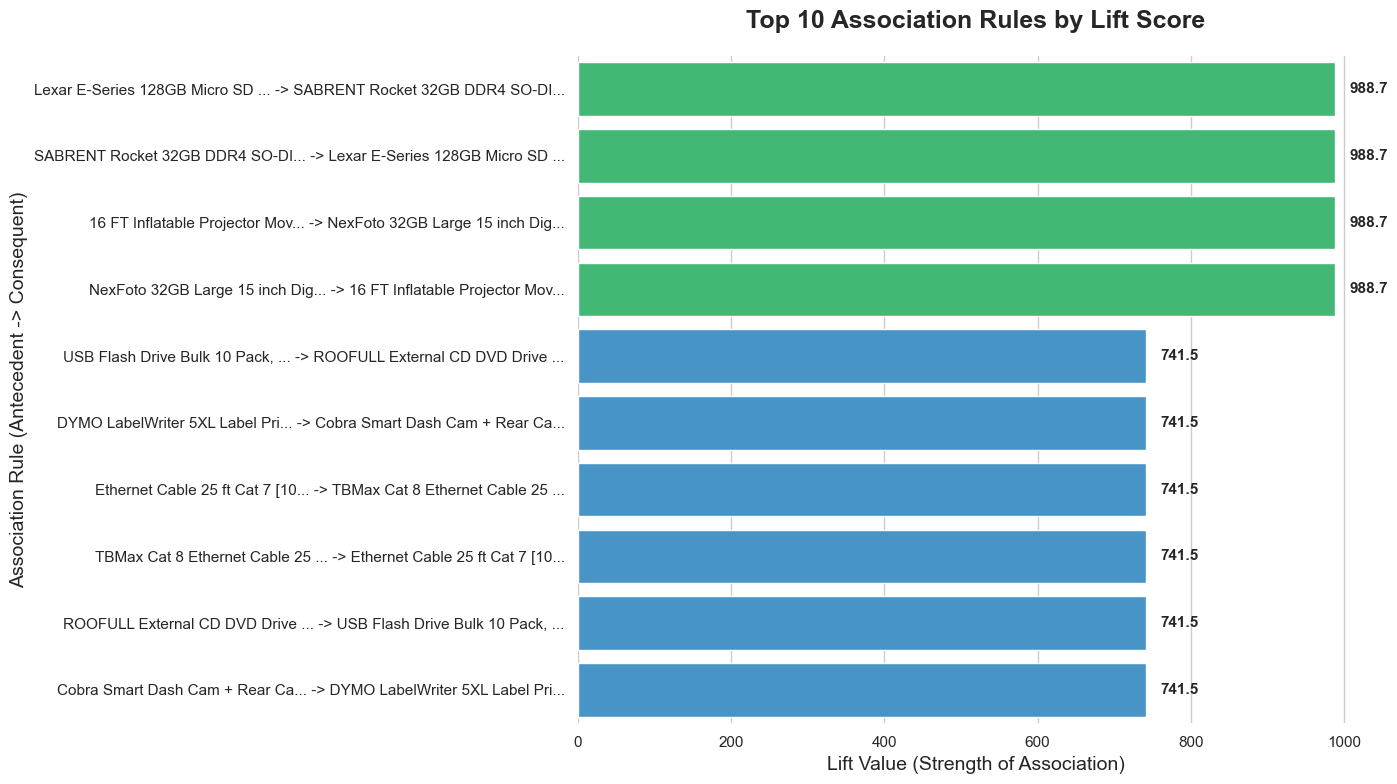

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

top_rules_visual = rules.sort_values(by='lift', ascending=False).head(10).copy()
top_rules_visual['rule_label'] = top_rules_visual['antecedents'].apply(lambda x: list(x)[0][:30] + "...") + " -> " + \
                                 top_rules_visual['consequents'].apply(lambda x: list(x)[0][:30] + "...")

max_lift = top_rules_visual['lift'].max()
colors = ['#2ecc71' if (val == max_lift) else '#3498db' for val in top_rules_visual['lift']]

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=top_rules_visual, 
    x='lift', 
    y='rule_label', 
    palette=colors
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=10, fontsize=11, fontweight='bold')

plt.title('Top 10 Association Rules by Lift Score', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Lift Value (Strength of Association)', fontsize=14)
plt.ylabel('Association Rule (Antecedent -> Consequent)', fontsize=14)

sns.despine(left=True, bottom=True)
plt.tight_layout()

output_path = os.path.join(CHARTS_OUTPUT, 'top_rules_lift_final.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')

print(f"Visualization saved successfully to: {output_path}")
plt.show()


Recommendation System Function

In [ ]:
def recommend_product(product_name, rules_df, top_n=3):
    """
    Logic: Customers who bought X also bought Y
    Uses CF and Lift for ranking.
    """

    recs = rules_df[rules_df['antecedents'].apply(lambda x: product_name in x)]
    recs = recs.sort_values(by=['certainty_factor', 'lift'], ascending=False)
    
    titles = recs['consequents'].apply(lambda x: list(x)[0]).unique()
    return titles[:top_n]


try:
    test_item = list(frequent_itemsets['itemsets'].iloc[0])[0]
    print(f" Top Recommendations for: '{test_item}'")
    results = recommend_product(test_item, rules)
    for i, res in enumerate(results, 1):
        print(f"   {i}. {res}")
except:
    print("No items found to test.")

 Top Recommendations for: 'Fire TV Stick with Alexa Voice Remote, streaming media player - Previous Generation'
   1. Echo Dot (2nd Generation) - Smart speaker with Alexa - White
   2. Seagate Backup Plus Portable 5TB External Hard Drive HDD – Red USB 3.0 for PC Laptop and Mac, 2 Months Adobe CC Photography (STDR5000103)
   3. Fire TV Stick 4K streaming device with Alexa Voice Remote (includes TV controls) | Dolby Vision


In [ ]:
import os
rules_path = "../data/processed_transactions/association_rules.csv"
os.makedirs(os.path.dirname(rules_path), exist_ok=True)

rules_to_save = rules.copy()
rules_to_save['antecedents'] = rules_to_save['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_to_save['consequents'] = rules_to_save['consequents'].apply(lambda x: ', '.join(list(x)))

rules_to_save.to_csv(rules_path, index=False)

print(f" Rules saved successfully to: {rules_path}")
print(f" Total Rules: {len(rules_to_save)}")

 Rules saved successfully to: ../data/processed_transactions/association_rules.csv
 Total Rules: 114
